In [1]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
# This ensures the same random numbers are generated every time
np.random.seed(23) 

# Mean vector for class 1
# Data points will be centered around (0,0,0)
mu_vec1 = np.array([0,0,0])

# Covariance matrix for class 1
# Identity matrix means features are independent 
# and each has variance = 1
cov_mat1 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

# Generate 20 samples from multivariate normal distribution
# for class 1
class1_sample = np.random.multivariate_normal(
    mu_vec1,
    cov_mat1,
    20
)

# Create DataFrame with 3 feature columns
df = pd.DataFrame(
    class1_sample,
    columns=['feature1','feature2','feature3']
)

# Assign target label = 1 to all class 1 samples
df['target'] = 1


# Mean vector for class 2
# Data points will be centered around (1,1,1)
mu_vec2 = np.array([1,1,1])

# Covariance matrix for class 2
cov_mat2 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

# Generate 20 samples for class 2
class2_sample = np.random.multivariate_normal(
    mu_vec2,
    cov_mat2,
    20
)

# Create DataFrame for class 2 samples
df1 = pd.DataFrame(
    class2_sample,
    columns=['feature1','feature2','feature3']
)

# Assign target label = 0 to all class 2 samples
df1['target'] = 0

# Combine both class DataFrames into a single DataFrame
# ignore_index=True resets the index
df = pd.concat([df, df1], ignore_index=True)

# Shuffle all 40 rows randomly
df = df.sample(40)

# Display first 5 rows
print(df.head())

    feature1  feature2  feature3  target
2  -0.367548 -1.137460 -1.322148       1
34  0.177061 -0.598109  1.226512       0
14  0.420623  0.411620 -0.071324       1
11  1.968435 -0.547788 -0.679418       1
12 -2.506230  0.146960  0.606195       1


In [2]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


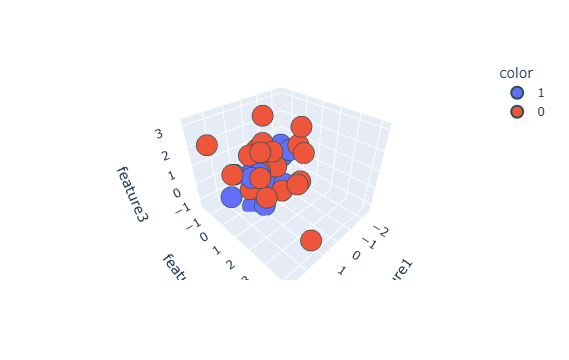

In [3]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [4]:
# Step 1 - Apply standard scaling for mean centring 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [5]:
# Step 2 - Find Covariance Matrix provide columns  
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [6]:
# Step 3 - Finding EV and EVs eigenvectors and eigenvalues
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [7]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [8]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

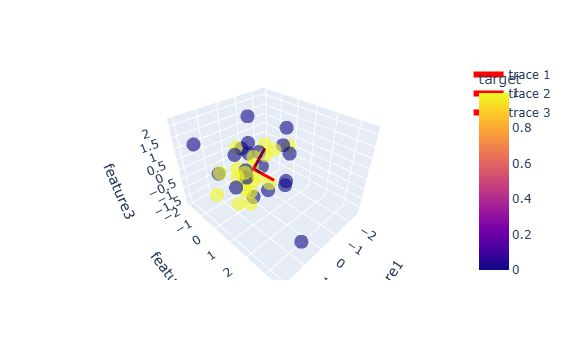

In [10]:
# Modern PCA visualization using Plotly

import plotly.express as px
from sklearn.decomposition import PCA

# features only
X = df[['feature1','feature2','feature3']]

# apply PCA
pca = PCA(n_components=3)
pca.fit(X)

# eigen vectors
vectors = pca.components_

# 3D scatter plot
fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='feature3',
    color='target',
    opacity=0.6
)

# mean point
mean = X.mean().values

# draw eigen vectors
for v in vectors:
    fig.add_scatter3d(
        x=[mean[0], mean[0] + v[0]],
        y=[mean[1], mean[1] + v[1]],
        z=[mean[2], mean[2] + v[2]],
        mode='lines',
        line=dict(color='red', width=6)
    )

fig.show()

In [11]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [15]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
#40,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


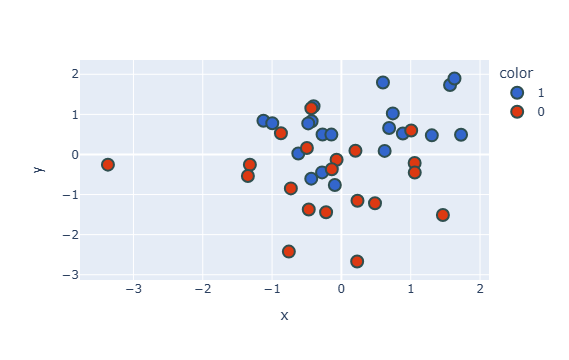

In [16]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()